In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [16]:
# Load your CSV
csv_file = r"metrics_summary.csv"  # path to your CSV
df = pd.read_csv(csv_file)
df.head()


,adapt,network,dataset,TP,FP,FN,TN,precision,recall,accuracy,f1
0,0,iiss_4b,Calb01uLED_hippo_2022-12-21_17-39-06_1558um,67,7,7,0,0.905405,0.905405,0.827160,0.905405
1,0,iiss_4b,Calb01uLED_hippo_2023-01-12_10-19-17_1558um,8,1,741,0,0.888889,0.010681,0.010667,0.021108
2,0,iiss_5b,Calb01uLED_hippo_2022-12-21_17-39-06_1558um,66,13,8,0,0.835443,0.891892,0.758621,0.862745
3,0,iiss_5b,Calb01uLED_hippo_2023-01-12_10-19-17_1558um,66,1,683,0,0.985075,0.088117,0.088000,0.161765
4,0,iiss_6b,Calb01uLED_hippo_2022-12-21_17-39-06_1558um,73,85,1,0,0.462025,0.986486,0.459119,0.629310


In [37]:
# --- 1. Quick look at best networks by F1 per adapt ---
pd.set_option("display.precision", 3)  # 3 decimals for all floats
best_by_f1 = df.loc[df.groupby([ 'dataset','adapt'])['f1'].idxmax()]
print("Best networks per adapt (by F1):")
print(best_by_f1[['adapt', 'dataset', 'network', 'f1', 'precision', 'recall']])

print("Dataset 1 (Low IISs frequency):")
print(best_by_f1[best_by_f1['dataset'] == 'Calb01uLED_hippo_2022-12-21_17-39-06_1558um'][['adapt', 'network', 'f1', 'precision', 'recall']])

print("Dataset 2 (High IISs frequency):")
print(best_by_f1[best_by_f1['dataset'] == 'Calb01uLED_hippo_2023-01-12_10-19-17_1558um'][['adapt', 'network', 'f1', 'precision', 'recall']])


Best networks per adapt (by F1):
    adapt                                      dataset          network  \
0       0  Calb01uLED_hippo_2022-12-21_17-39-06_1558um          iiss_4b   
18     20  Calb01uLED_hippo_2022-12-21_17-39-06_1558um  iiss_adapt20_2b   
20     60  Calb01uLED_hippo_2022-12-21_17-39-06_1558um          iiss_4b   
30    120  Calb01uLED_hippo_2022-12-21_17-39-06_1558um          iiss_4b   
5       0  Calb01uLED_hippo_2023-01-12_10-19-17_1558um          iiss_6b   
13     20  Calb01uLED_hippo_2023-01-12_10-19-17_1558um          iiss_5b   
21     60  Calb01uLED_hippo_2023-01-12_10-19-17_1558um          iiss_4b   
31    120  Calb01uLED_hippo_2023-01-12_10-19-17_1558um          iiss_4b   

       f1  precision  recall  
0   0.905      0.905   0.905  
18  0.776      0.643   0.978  
20  0.807      0.676   1.000  
30  0.807      0.676   1.000  
5   0.267      0.975   0.155  
13  0.826      0.860   0.794  
21  0.954      0.911   1.000  
31  0.954      0.911   1.000  
Dataset 1 (L

In [44]:
aggregated = df.groupby(['dataset','adapt']).agg(mean_precision=('precision', 'mean'),mean_recall=('recall', 'mean'), mean_f1=('f1', 'mean')).reset_index()
print(aggregated[aggregated['dataset'] == 'Calb01uLED_hippo_2022-12-21_17-39-06_1558um'].drop(columns=['dataset']))

print(aggregated[aggregated['dataset'] == 'Calb01uLED_hippo_2023-01-12_10-19-17_1558um'].drop(columns=['dataset']))

   adapt  mean_precision  mean_recall  mean_f1
0      0           0.787        0.889    0.818
1     20           0.504        0.965    0.635
2     60           0.516        0.961    0.644
3    120           0.534        0.965    0.660
   adapt  mean_precision  mean_recall  mean_f1
4      0           0.918        0.055    0.098
5     20           0.881        0.733    0.798
6     60           0.905        0.981    0.941
7    120           0.905        0.981    0.941


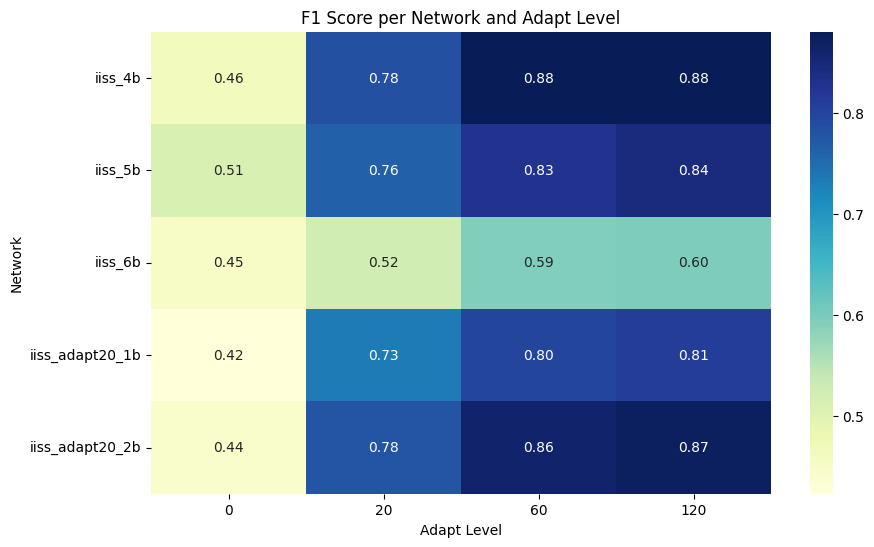

In [12]:
# --- 2. Heatmap of metrics for all networks ---
metrics = ['precision', 'recall', 'accuracy', 'f1']
pivot = df.pivot_table(index='network', columns='adapt', values='f1')  # F1 heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("F1 Score per Network and Adapt Level")
plt.ylabel("Network")
plt.xlabel("Adapt Level")
plt.show()



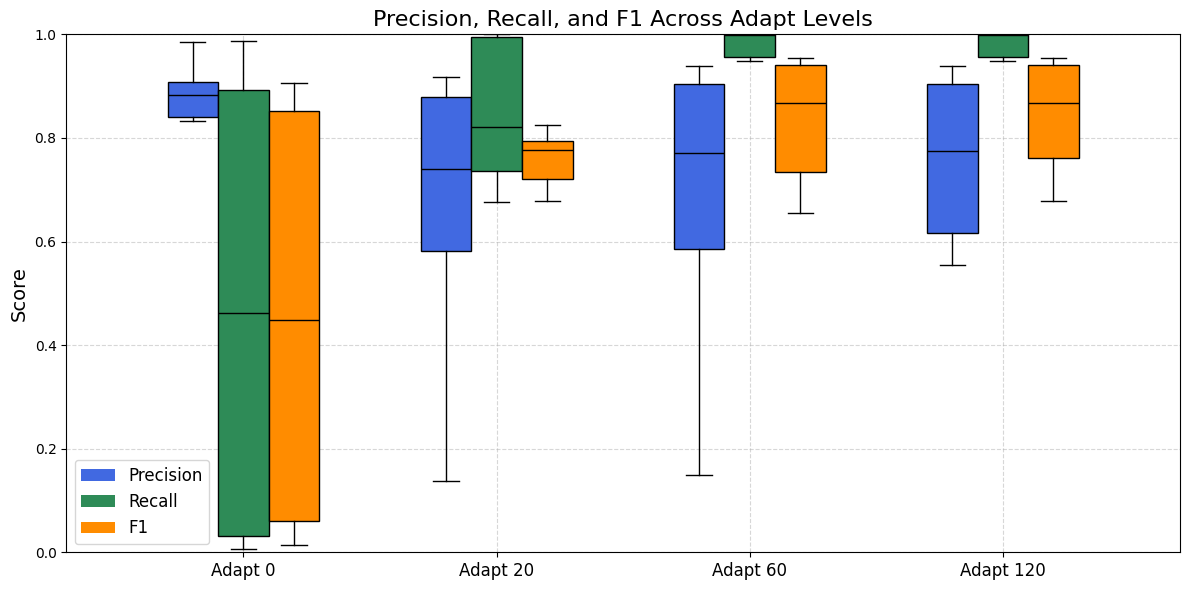

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Precision, Recall, and F1 Across Adapt Levels'}, ylabel='Score'>)

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_metrics_across_adapt(df, metrics=["precision", "recall", "f1"], colors=None):
    """
    Boxplot-like visualization of metrics across adapt levels.
    
    Args:
        df (pd.DataFrame): Must have columns ['adapt', 'network', 'dataset', ...metrics...]
        metrics (list): List of metrics to plot.
        colors (dict): Optional dict mapping metric -> color.
    """
    if colors is None:
        colors = {"precision": "royalblue", "recall": "seagreen", "f1": "darkorange"}

    adapt_levels = sorted(df['adapt'].unique())
    width = 0.2
    fig, ax = plt.subplots(figsize=(12,6))

    for i, metric in enumerate(metrics):
        metric_values = []
        positions = []
        for j, adapt in enumerate(adapt_levels):
            vals = df[df['adapt'] == adapt][metric].values
            pos = j + i*width - width  # slight shift for grouped bars
            positions.append(pos)
            metric_values.append(vals)

        # Draw boxplots for this metric
        for pos, vals in zip(positions, metric_values):
            bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                               showfliers=False, medianprops=dict(color='black'))
            for patch in bplot['boxes']:
                patch.set_facecolor(colors.get(metric, "gray"))

    # X-axis ticks
    ax.set_xticks(range(len(adapt_levels)))
    ax.set_xticklabels([f"Adapt {a}" for a in adapt_levels], fontsize=12)
    ax.set_ylabel("Score", fontsize=14)
    ax.set_title("Precision, Recall, and F1 Across Adapt Levels", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(0,1)

    # Legend
    legend_handles = [Patch(facecolor=colors[m], label=m.capitalize()) for m in metrics]
    ax.legend(handles=legend_handles, fontsize=12, loc='best')

    plt.tight_layout()
    plt.show()
    return fig, ax


# --- Example usage ---
# df = pd.read_csv("metrics_summary.csv")
plot_metrics_across_adapt(df, metrics=["precision","recall","f1"])


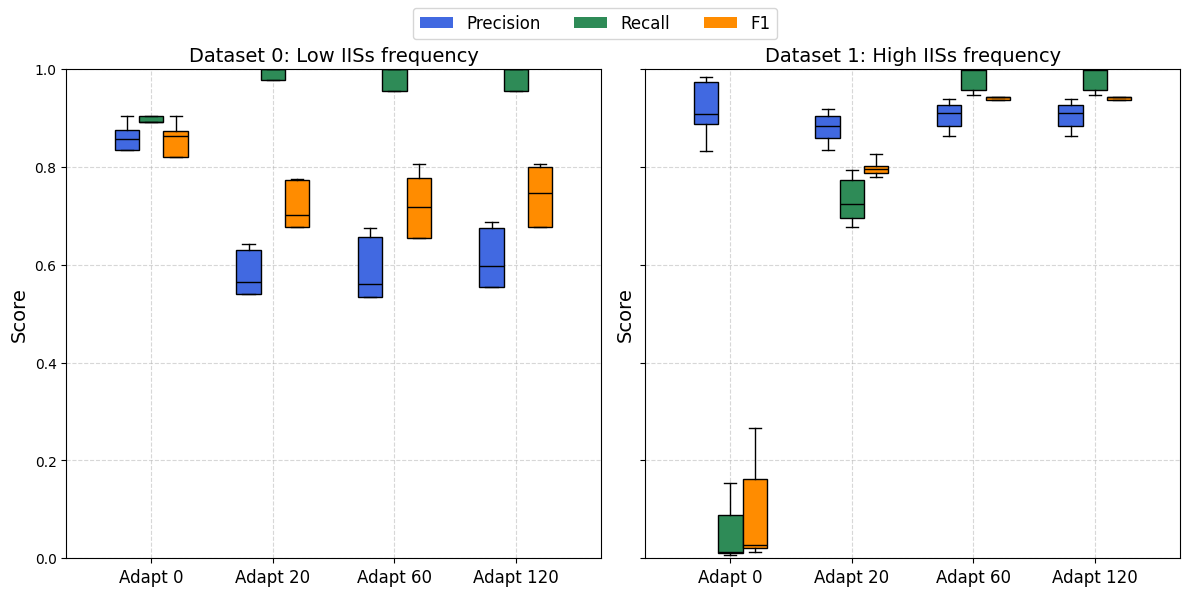

In [51]:
def plot_metrics_across_adapt_by_dataset(df, metrics=["precision", "recall", "f1"], colors=None):
    """
    Boxplot-like visualization of metrics across adapt levels,
    separated by dataset (side-by-side subplots).
    
    Args:
        df (pd.DataFrame): Must have columns ['adapt', 'network', 'dataset', ...metrics...]
        metrics (list): List of metrics to plot.
        colors (dict): Optional dict mapping metric -> color.
    """
    if colors is None:
        colors = {"precision": "royalblue", "recall": "seagreen", "f1": "darkorange"}

    adapt_levels = sorted(df['adapt'].unique())
    datasets = df['dataset'].unique()
    width = 0.2

    fig, axes = plt.subplots(1, len(datasets), figsize=(6*len(datasets), 6), sharey=True)
    data=["Low IISs frequency", "High IISs frequency"]
    if len(datasets) == 1:
        axes = [axes]

    for idx, (ax, dataset) in enumerate(zip(axes, datasets)):
        df_subset = df[df['dataset'] == dataset]

        for i, metric in enumerate(metrics):
            metric_values = []
            positions = []
            for j, adapt in enumerate(adapt_levels):
                vals = df_subset[df_subset['adapt'] == adapt][metric].values
                pos = j + i*width - width  # shift for grouped boxplots
                positions.append(pos)
                metric_values.append(vals)

            # Draw boxplots for this metric
            for pos, vals in zip(positions, metric_values):
                bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                                   showfliers=False, medianprops=dict(color='black'))
                for patch in bplot['boxes']:
                    patch.set_facecolor(colors.get(metric, "gray"))

        # X-axis ticks
        ax.set_xticks(range(len(adapt_levels)))
        ax.set_xticklabels([f"Adapt {a}" for a in adapt_levels], fontsize=12)
        ax.set_ylabel("Score", fontsize=14)
        ax.set_title(f"Dataset {idx}: {data[idx]}", fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_ylim(0, 1)

    # Legend (shared)
    legend_handles = [Patch(facecolor=colors[m], label=m.capitalize()) for m in metrics]
    fig.legend(handles=legend_handles, fontsize=12, loc='upper center', ncol=len(metrics))

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()
    return fig, axes

fig, axes=plot_metrics_across_adapt_by_dataset(df, metrics=["precision", "recall", "f1"])